# Word2Vec Tutorial with Gensim

In [134]:
# !pip install gensim

In [135]:
# imports

import pandas as pd
import json
import string
from collections import Counter
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import utils
import wikipediaapi
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

%matplotlib inline

Data pre-processing to make it readable by json.load()

In [136]:
# Load and display data

with open('country_list.json', 'r', encoding='utf-8') as fout:
    country_names = json.load(fout)

In [137]:
country_names = pd.DataFrame(country_names)
country_names.head()

,name,code
0,Afghanistan,AF
1,land Islands,AX
2,Albania,AL
3,Algeria,DZ
4,American Samoa,AS


In [138]:
# Set a user-agent for politeness
user_email = "arni.genius@gmail.com"

# Initialize Wikipedia API with a proper user agent
wiki_wiki = wikipediaapi.Wikipedia(user_agent=user_email, language="en")

# List of countries
countries = country_names.name.to_list()

# Dictionary to store country summaries
country_data = {}

# Fetch Wikipedia summary for each country
for country in countries:
    page = wiki_wiki.page(country)
    if page.exists():       # create non-punctuation token list for each country-key
        country_data[country] = [w for w in word_tokenize(page.text) 
                                 if w not in string.punctuation]


In [139]:
countries = country_data
countries.keys()

dict_keys(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'AndorrA', 'Angola', 'Anguilla', 'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Bouvet Island', 'Brazil', 'British Indian Ocean Territory', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chile', 'China', 'Christmas Island', 'Cocos (Keeling) Islands', 'Colombia', 'Comoros', 'Congo', 'Congo, The Democratic Republic of the', 'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Ethiopia', 'Falkland Islands (Malvinas)', 'Faroe Islands', '

In [140]:
print(' '.join(countries['India'])[:512] + ' ...')

India officially the Republic of India is a country in South Asia It is the seventh-largest country by area the most populous country from June 2023 onwards and since its independence in 1947 the world 's most populous democracy Bounded by the Indian Ocean on the south the Arabian Sea on the southwest and the Bay of Bengal on the southeast it shares land borders with Pakistan to the west China Nepal and Bhutan to the north and Bangladesh and Myanmar to the east In the Indian Ocean India is near Sri Lanka an ...


In [141]:
for i, (country, text) in enumerate(countries.items()):
    print(country)
    print(' '.join(text)[:512] + ' ...')
    print('-' * 100)
    if i >= 5:
        break

Afghanistan
Afghanistan officially the Islamic Emirate of Afghanistan is a landlocked country located at the crossroads of Central Asia and South Asia It is bordered by Pakistan to the east and south Iran to the west Turkmenistan to the northwest Uzbekistan to the north Tajikistan to the northeast and China to the northeast and east Occupying 652,864 square kilometers 252,072 sq mi of land the country is predominantly mountainous with plains in the north and the southwest which are separated by the Hindu Kush mountain  ...
----------------------------------------------------------------------------------------------------
Albania
Albania a w l-BAY-nee-ə Albanian Shqipëri or Shqipëria officially the Republic of Albania Albanian Republika e Shqipërisë is a country in Southeast Europe It is located in the Balkans on the Adriatic and Ionian Seas within the Mediterranean Sea and shares land borders with Montenegro to the northwest Kosovo to the northeast North Macedonia to the east and Gree

## Basic Word2Vec Usage

In [142]:
# Create and train a simple model

model = Word2Vec(sentences= countries.values())     # list of list of tokens

### Word2Vec options

In [143]:
model.corpus_total_words

2366972

In [144]:
model.wv.most_similar(['India'], topn= 5)

[('Korea', 0.7781822085380554),
 ('China', 0.7781553268432617),
 ('Arabia', 0.7748541235923767),
 ('Iran', 0.7679730653762817),
 ('Sudan', 0.7657836675643921)]

In [145]:
model = Word2Vec(
    sentences= countries.values(),
    compute_loss= True
)

model.get_latest_training_loss()

5780367.5

In [146]:
# Word2Vec?

## Heuristics for Word2vec algorithms

### Determining size of the vocabulary

In [147]:
# How many unique words in the vocabulary?

counter = Counter()
for words in countries.values():
    for word in words:
        counter.update([word])

print(len(counter))

108879


In [148]:
# counter

In [149]:
# Default vocabulary size of the original model

len(model.wv)

22701

Loss after epoch 0: 1567966.375
Loss after epoch 1: 1210034.125
Loss after epoch 2: 1066970.75
Loss after epoch 3: 936098.75
Loss after epoch 4: 867310.5
Loss after epoch 5: 843940.0
Loss after epoch 6: 809660.0
Loss after epoch 7: 813741.5
Loss after epoch 8: 725623.0
Loss after epoch 9: 673944.0


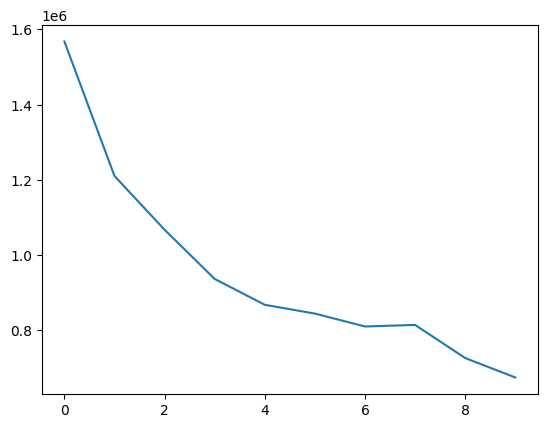

In [150]:
# Retrain - increased vocabulary size, more epochs, larger word vectors

metric = utils.MetricCallback(every=1)
model = Word2Vec(
    sentences= countries.values(),
    vector_size=128,
    epochs=10,
    max_vocab_size=65536,
    compute_loss=True,
    callbacks=[metric]      # code repeated at different stages of training process
)
plt.plot(metric.myloss)

In [151]:
# Check similarities again

model.wv.most_similar('India')

[('China', 0.6537731289863586),
 ('Pakistan', 0.6354077458381653),
 ('Japan', 0.6005525588989258),
 ('Korea', 0.5935800075531006),
 ('Sudan', 0.5929842591285706),
 ('Malaysia', 0.5922228097915649),
 ('Asia', 0.5753673315048218),
 ('Syria', 0.5749017000198364),
 ('Egypt', 0.5709762573242188),
 ('Thailand', 0.5657302737236023)]

Loss after epoch 0: 532803.125
Loss after epoch 10: 291676.25
Loss after epoch 20: 237789.5
Loss after epoch 30: 222759.0
Loss after epoch 40: 216519.0
Loss after epoch 50: 208591.0
Loss after epoch 60: 222800.0
Loss after epoch 70: 163304.0
Loss after epoch 80: 169562.0
Loss after epoch 90: 178212.0
Loss after epoch 100: 166666.0
Loss after epoch 110: 169592.0
Loss after epoch 120: 163424.0
Loss after epoch 130: 159618.0
Loss after epoch 140: 154710.0
Loss after epoch 150: 152728.0
Loss after epoch 160: 161486.0
Loss after epoch 170: 140502.0
Loss after epoch 180: 83416.0
Loss after epoch 190: 76816.0


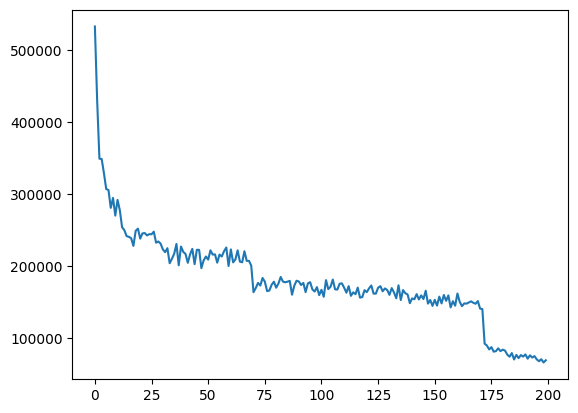

In [162]:
# Retrain - more epochs

metric = utils.MetricCallback(every=10)
model = Word2Vec(
    sentences= countries.values(),
    vector_size=128,
    epochs=200,
    # max_vocab_size=65536,
    compute_loss=True,
    callbacks=[metric],
    min_alpha=0.001,
    workers=9
)
plt.plot(metric.myloss)

In [163]:
model.wv.most_similar('Russia')

[('Ukraine', 0.6695210933685303),
 ('Poland', 0.6621944308280945),
 ('Belarus', 0.6019772887229919),
 ('Iran', 0.5690873265266418),
 ('Turkey', 0.5559000372886658),
 ('Kazakhstan', 0.5553544759750366),
 ('China', 0.5502549409866333),
 ('Japan', 0.5451183319091797),
 ('Armenia', 0.5362881422042847),
 ('Romania', 0.5245848298072815)]

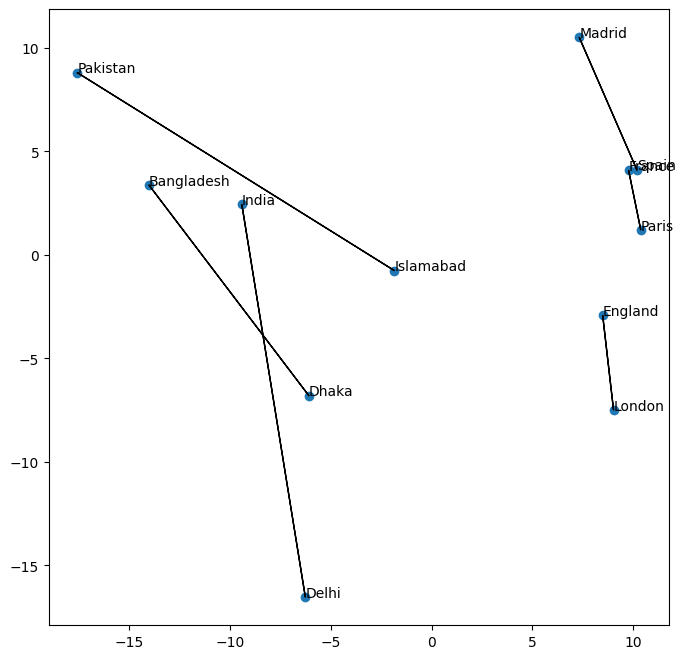

In [164]:
# Examine the vector space

X = ['India', 'Pakistan', 'Bangladesh', 'France', 'England', 'Spain']
Y = ['Delhi', 'Islamabad', 'Dhaka', 'Paris', 'London', 'Madrid']
utils.plot_arrows(X, Y, model.wv)

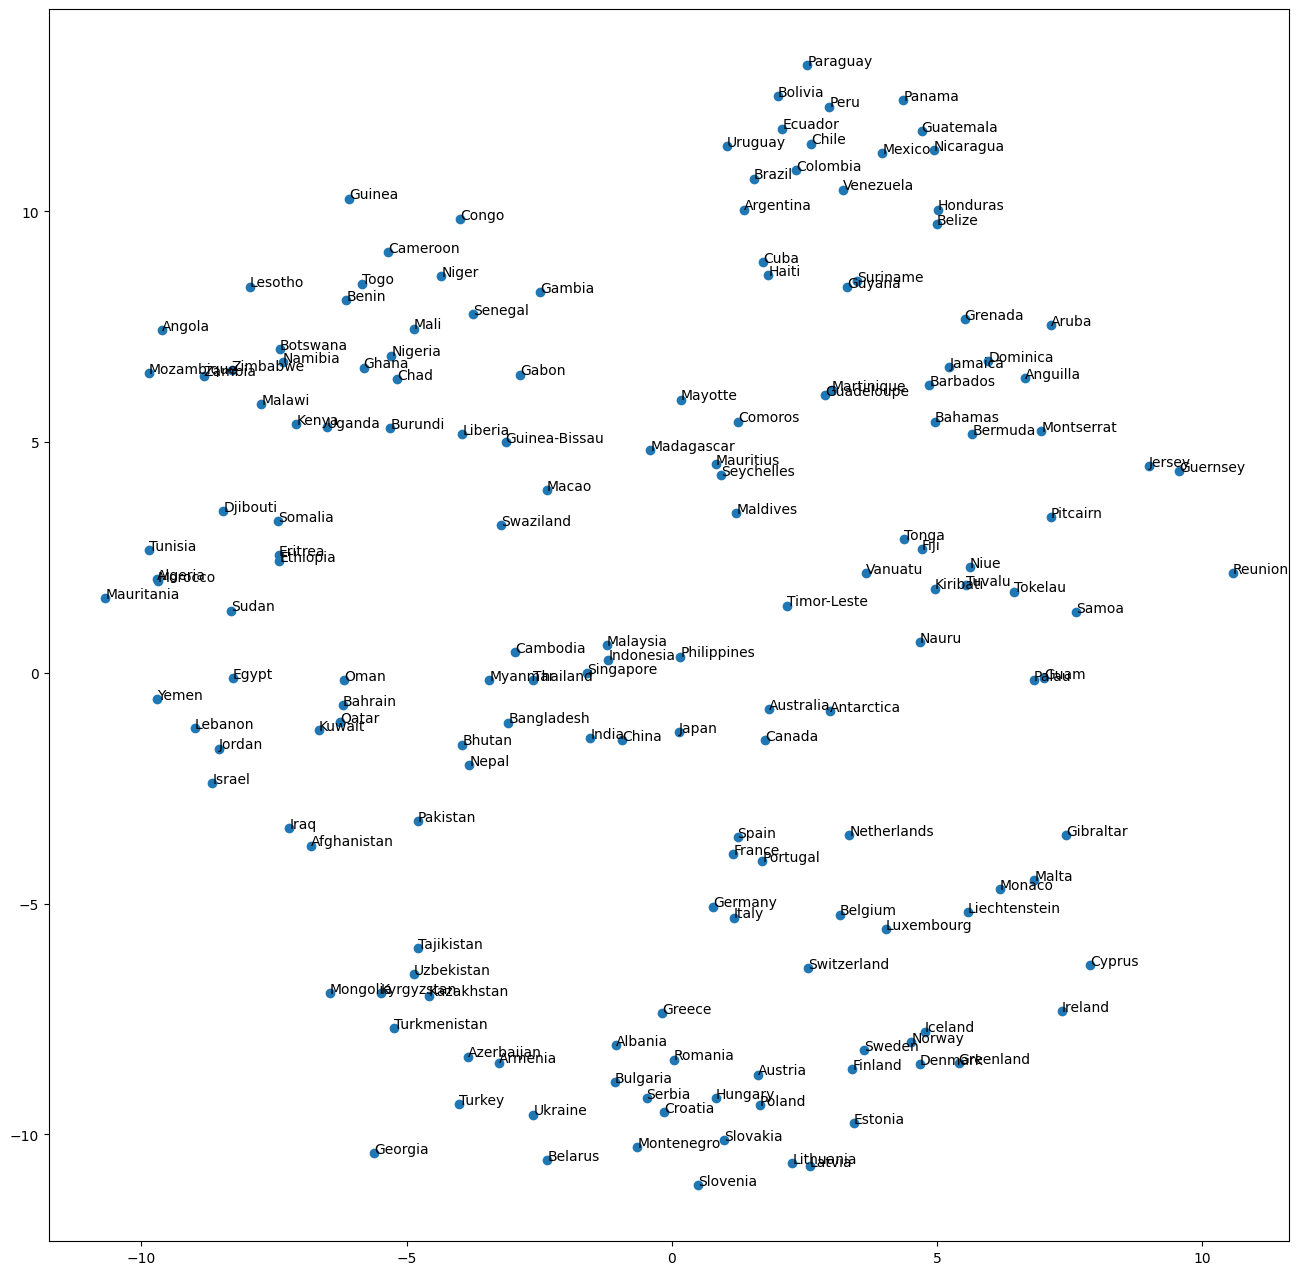

In [165]:
# Visualize vectors for all countries

utils.plot_vectors(countries, model)

## Word Analogies

In [166]:
# India: Ganges -> Brazil: __ ?

model.wv.most_similar(positive=['Himalayas', 'Brazil'], negative=['India'])

[('Andes', 0.40620559453964233),
 ('Llanos', 0.3925110399723053),
 ('valleys', 0.3877904415130615),
 ('subduction', 0.3752075135707855),
 ('Karakum', 0.37391406297683716),
 ('cloud', 0.36622804403305054),
 ('Cordillera', 0.36091405153274536),
 ('basins', 0.3548800051212311),
 ('rivers', 0.35203444957733154),
 ('Slovenia', 0.3507859408855438)]

In [167]:
# America: Washington -> France: __ ?

model.wv.most_similar(positive=['Hollywood', 'India'], negative=['America'])

[('Delhi', 0.4533756971359253),
 ('Bollywood', 0.4192407429218292),
 ('jute', 0.411113440990448),
 ('Bangladesh', 0.40517866611480713),
 ('Afghanistan', 0.4017571210861206),
 ('Duars', 0.3946564495563507),
 ('Pakistan', 0.3883369565010071),
 ('Kilwa', 0.3870382010936737),
 ('Bhutan', 0.3734491467475891),
 ('Kerala', 0.3675384521484375)]

In [168]:
# India: Hindi -> Germany: __ ?

model.wv.most_similar(positive=['Hindi', 'Germany'], negative=['India'])

[('German', 0.38035666942596436),
 ('dialect', 0.374651700258255),
 ('Brussels', 0.36963069438934326),
 ('co-hosted', 0.3686900734901428),
 ('Romani', 0.36361077427864075),
 ('Indo-Trinidadians', 0.3543737530708313),
 ('German-speaking', 0.33421552181243896),
 ('Marko', 0.328183650970459),
 ('Aromanian', 0.32571277022361755),
 ('Marcel', 0.32345494627952576)]

In [169]:
# Save the model

model.save('wiki-countries.w2v')

In [170]:
from gensim.models import KeyedVectors
model = KeyedVectors.load('wiki-countries.w2v')

In [171]:
model